# Week 2 — Notebook 3: Comparative Analysis (Bonus)

This notebook contains analysis questions that require you to **write code and explain your findings**.

For each question:
1. Write your code in the empty cell below the question
2. Add a short written answer (2–4 sentences) in a markdown cell after your output

You may load processed CSVs from `data/processed/` or recompute indicators directly from `data/raw/`.

> Charts must have titles, axis labels, and legends. Written answers must reference specific dates or numbers from your output.

---

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


BASE_DIR      = Path('/content/drive/MyDrive/MarketTradingCourse')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.', '_').replace('=','_').replace('-','_')

def load_features(symbol: str) -> pd.DataFrame:
    return pd.read_csv(PROCESSED_DIR / f'{safe_symbol(symbol)}_features.csv',
                       parse_dates=['date'], index_col='date')

print('Setup done.')

Setup done.


---

## Q1 — Which US stock had the highest average SMA-20 over 2020–2024?

Load the processed features for `AAPL`, `MSFT`, `NVDA`, `TSLA`, and `SPY`.
Filter to **2020-01-01 → 2024-12-31**.
For each symbol, compute the mean of its `sma_ratio_20` over that period (not the raw SMA value — the ratio tells you how far above/below average each stock typically trades).
Display results as a **horizontal bar chart**, sorted from highest to lowest.

**Answer in a markdown cell:** Which stock was most consistently above its 20-day average? What does a persistently positive sma_ratio suggest about its trend?

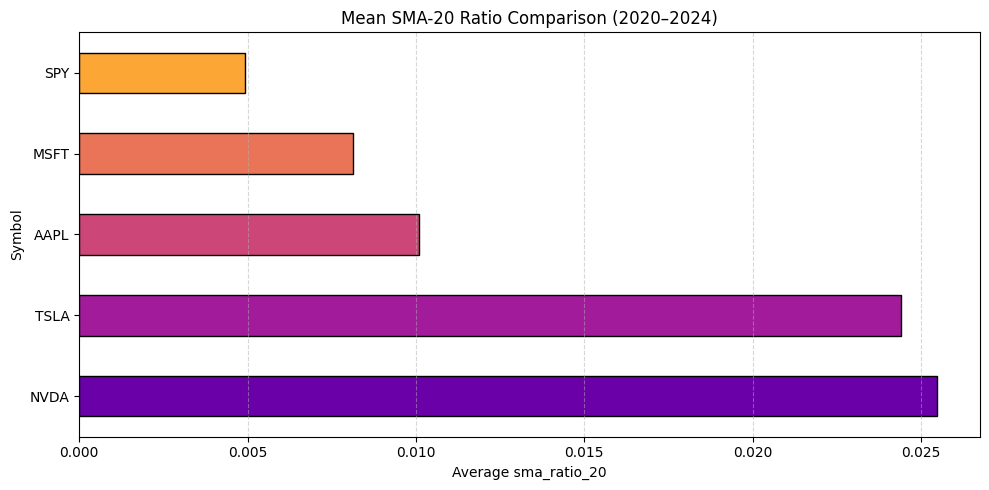

Calculated Mean Values:
 NVDA    0.025479
TSLA    0.024395
AAPL    0.010099
MSFT    0.008124
SPY     0.004917
dtype: float64


In [6]:
# Your code here
symbols = ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'SPY']
mean_ratios = {}

for sym in symbols:
    try:
        df_sym = load_features(sym)
        # Filter to the requested 2020-2024 window
        df_filtered = df_sym.loc['2020-01-01':'2024-12-31']
        mean_ratios[sym] = df_filtered['sma_ratio_20'].mean()
    except Exception as e:
        print(f"Error processing {sym}: {e}")

# Sort results from highest to lowest
sorted_ratios = pd.Series(mean_ratios).sort_values(ascending=False)

# Plot horizontal bar chart
plt.figure(figsize=(10, 5))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(sorted_ratios)))
sorted_ratios.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Mean SMA-20 Ratio Comparison (2020–2024)')
plt.xlabel('Average sma_ratio_20')
plt.ylabel('Symbol')
plt.grid(True, linestyle='--', alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

print("Calculated Mean Values:\n", sorted_ratios)



NVDA

## Q2 — Side-by-side RSI comparison: one Indian stock, one US stock, one crypto

Choose one symbol from each group:
- India: `RELIANCE.NS` or `TCS.NS`
- US: `AAPL`, `MSFT`, or `NVDA`
- Crypto: `BTC-USD` or `ETH-USD`

Plot their `rsi_14` in a **3-row subplot** sharing the x-axis, covering the most recent **two full years** of data.
Draw dashed lines at 0.70 (overbought) and 0.30 (oversold) on each panel.

**Answer in a markdown cell:** Which asset class spends the most time in extreme RSI territory (above 0.70 or below 0.30)? Give a possible reason.

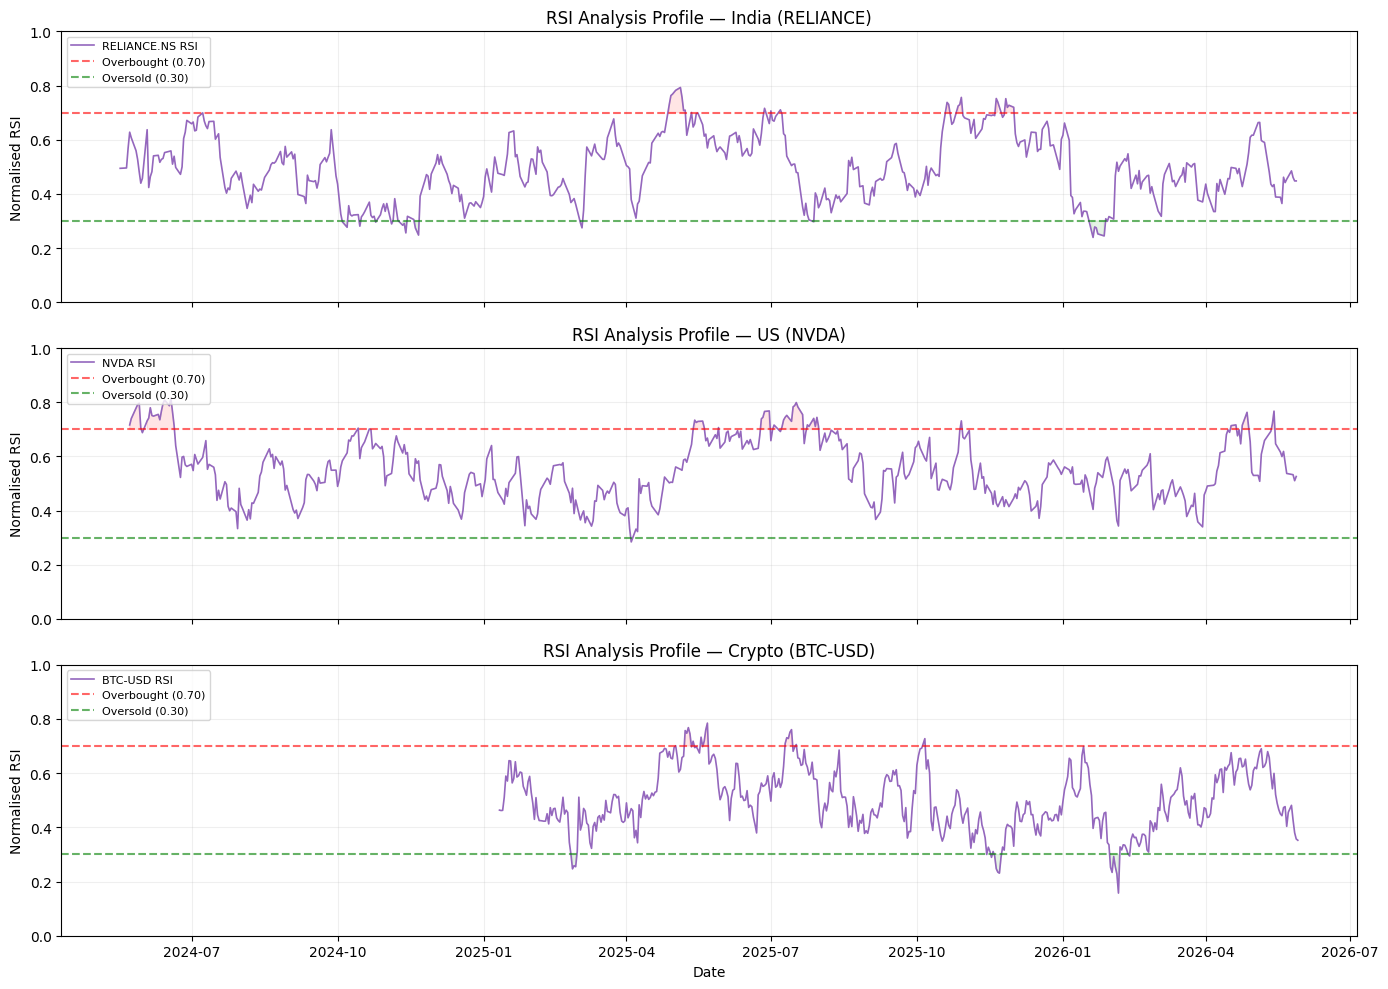

In [7]:
# Your code here
# Choosing representative assets from each group
assets = {
    'India (RELIANCE)': 'RELIANCE.NS',
    'US (NVDA)': 'NVDA',
    'Crypto (BTC-USD)': 'BTC-USD'
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, (label, sym) in enumerate(assets.items()):
    try:
        df_sym = load_features(sym)
        # Filter for the last two full trading years (~504 days)
        recent_df = df_sym.tail(504)

        axes[i].plot(recent_df.index, recent_df['rsi_14'], label=f'{sym} RSI', color='tab:purple', linewidth=1.2)
        axes[i].axhline(0.70, color='red', linestyle='--', alpha=0.6, label='Overbought (0.70)')
        axes[i].axhline(0.30, color='green', linestyle='--', alpha=0.6, label='Oversold (0.30)')

        # Shade outer boundaries
        axes[i].fill_between(recent_df.index, recent_df['rsi_14'], 0.70, where=(recent_df['rsi_14'] >= 0.70), color='red', alpha=0.1)
        axes[i].fill_between(recent_df.index, recent_df['rsi_14'], 0.30, where=(recent_df['rsi_14'] <= 0.30), color='green', alpha=0.1)

        axes[i].set_title(f'RSI Analysis Profile — {label}')
        axes[i].set_ylabel('Normalised RSI')
        axes[i].set_ylim(0, 1)
        axes[i].legend(loc='upper left', fontsize=8)
        axes[i].grid(True, alpha=0.2)
    except Exception as e:
        print(f"Error loading {sym}: {e}")

plt.xlabel('Date')
plt.tight_layout()
plt.show()

NVDA

## Q3 — MACD histogram comparison: AAPL vs MSFT vs NVDA

Plot the `macd_hist` column for all three symbols in a **3-row subplot** (shared x-axis, last two years).
Colour bars **green** when positive and **red** when negative so crossovers are visually clear.

Then count the number of histogram sign changes per symbol (i.e. how often does the bar switch from positive to negative or vice versa?).

**Answer in a markdown cell:** Which stock has the most sign changes? What does frequent sign-changing imply about that stock's trend consistency?

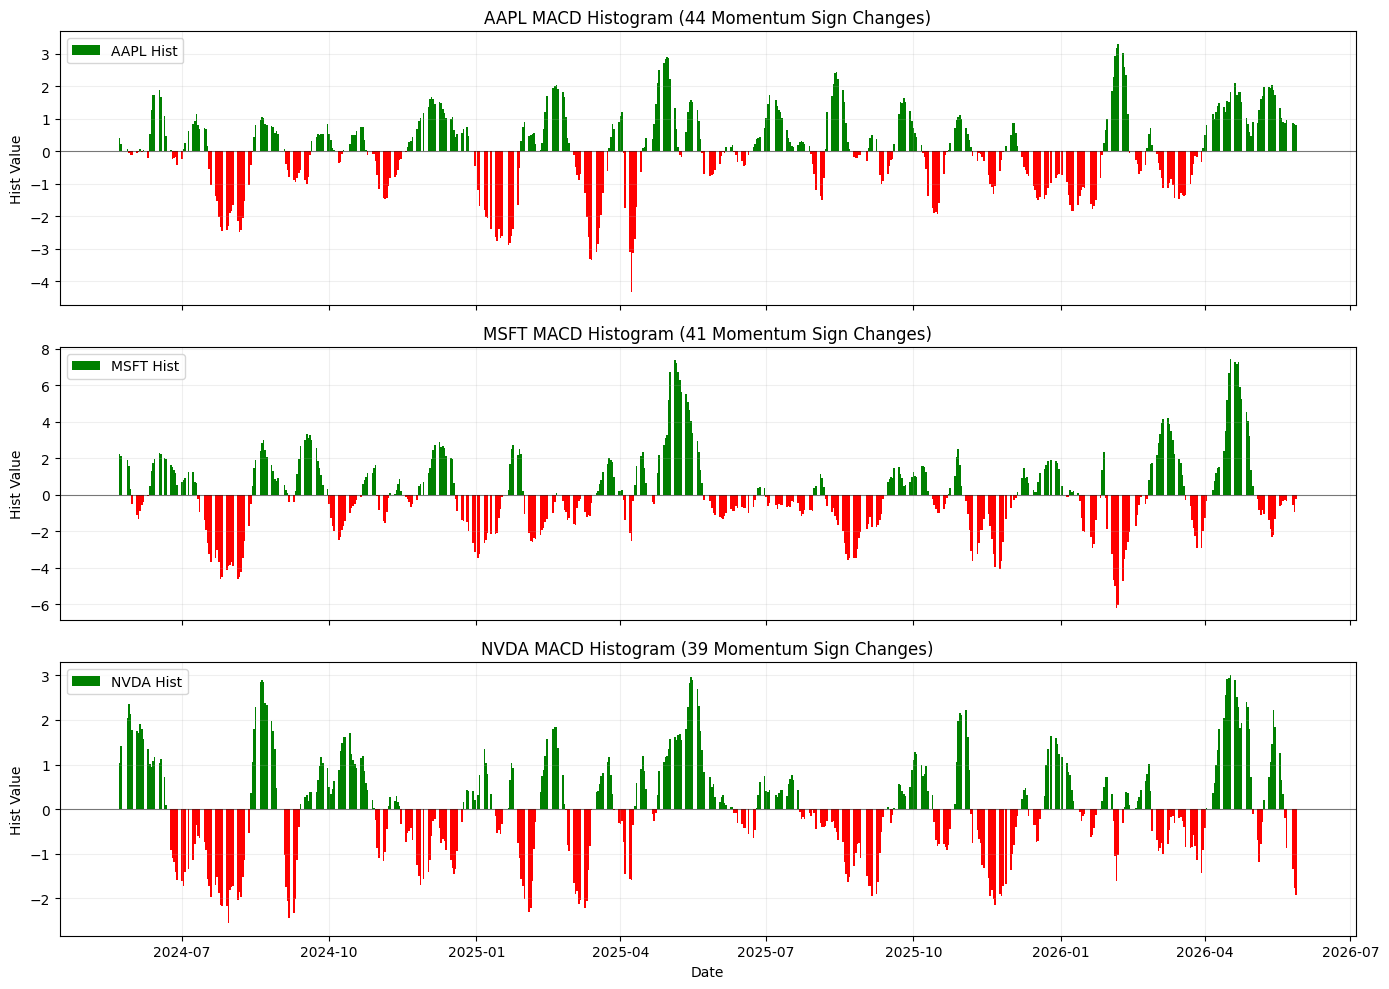

In [15]:
# Your code here
tech_symbols = ['AAPL', 'MSFT', 'NVDA']
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, sym in enumerate(tech_symbols):
    try:
        # Load processed features
        df_sym = load_features(sym).tail(504) # Slicing last 2 trading years

        # Reconstruct the MACD Histogram safely on the fly
        macd_hist_series = df_sym['macd'] - df_sym['macd_signal']

        # Determine bar colors dynamically based on sign
        colors = np.where(macd_hist_series >= 0, 'green', 'red')
        axes[i].bar(df_sym.index, macd_hist_series, color=colors, width=1.0, label=f'{sym} Hist')

        # --- SAFE SIGN CHANGE COUNTING ---
        # 1. Map values to boolean arrays: True if positive, False if negative
        is_positive = (macd_hist_series >= 0).astype(int)

        # 2. Shift the series by 1 day to find where today's sign doesn't match yesterday's
        sign_changes = (is_positive != is_positive.shift(1))

        # 3. Sum up the changes (ignoring the very first row which becomes NaN on shift)
        total_crosses = sign_changes.iloc[1:].sum()
        # ----------------------------------

        axes[i].axhline(0, color='black', linewidth=0.8, alpha=0.5)
        axes[i].set_title(f'{sym} MACD Histogram ({total_crosses} Momentum Sign Changes)')
        axes[i].set_ylabel('Hist Value')
        axes[i].legend(loc='upper left')
        axes[i].grid(True, alpha=0.2)
    except Exception as e:
        print(f"Error plotting {sym}: {e}")

plt.xlabel('Date')
plt.tight_layout()
plt.show()

AAPL

## Q4 — Volatility comparison: which symbol has the widest Bollinger Bands on average?

Load processed features for at least **six symbols** spanning at least two markets.
Compute the **mean `bb_width`** for each symbol over its full available history.
Plot as a sorted bar chart.

Then for the **most volatile symbol**, plot its close price with Bollinger Bands and highlight the top-10% widest-band periods with a shaded background.

**Answer in a markdown cell:** What event or characteristic of that asset explains why its bands are wider than the others?

Most volatile symbol selected: BTC-USD


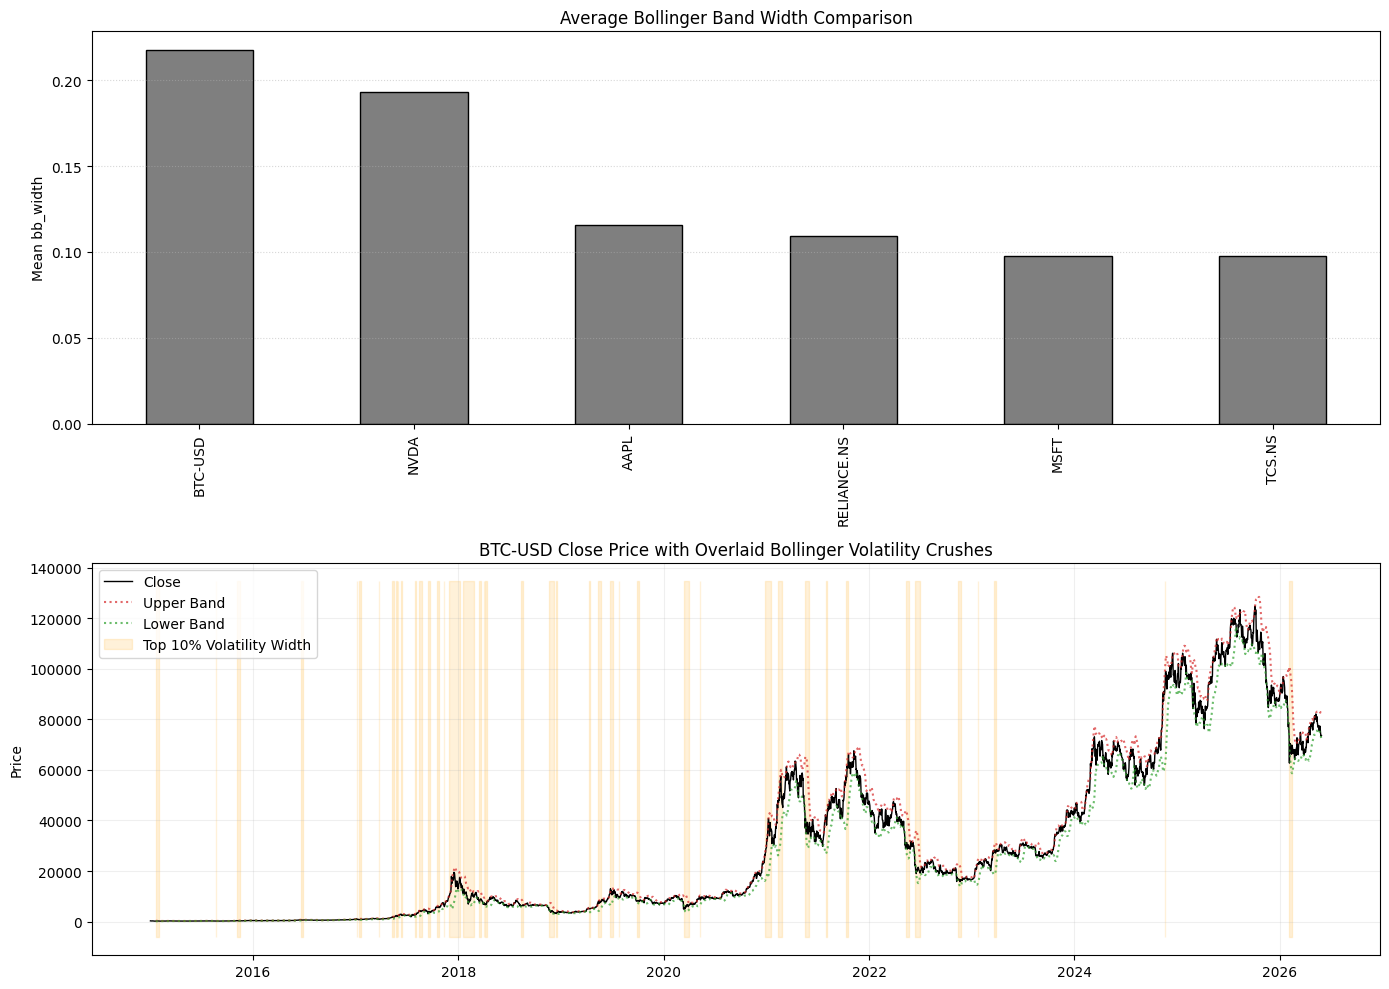

In [9]:
# Your code here
# Selecting six symbols across various asset tracking types
test_universe = ['AAPL', 'MSFT', 'NVDA', 'RELIANCE.NS', 'TCS.NS', 'BTC-USD']
mean_widths = {}

for sym in test_universe:
    try:
        mean_widths[sym] = load_features(sym)['bb_width'].mean()
    except Exception as e:
        print(f"Missing data tracking for {sym}: {e}")

# Process bar chart sorting layout sequence
sorted_widths = pd.Series(mean_widths).sort_values(ascending=False)

# Identify the absolute highest volatility symbol
most_volatile_sym = sorted_widths.index[0]
print(f"Most volatile symbol selected: {most_volatile_sym}")

# Plot 1: Sorted bar chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
sorted_widths.plot(kind='bar', color='tab:gray', ax=ax1, edgecolor='black')
ax1.set_title('Average Bollinger Band Width Comparison')
ax1.set_ylabel('Mean bb_width')
ax1.grid(True, linestyle=':', alpha=0.5, axis='y')

# Plot 2: Volatility structure highlighting on raw price path
df_vol = pd.read_csv(RAW_DIR / f"{safe_symbol(most_volatile_sym)}.csv", parse_dates=['date']).set_index('date')
df_feat = load_features(most_volatile_sym)

# Align the calculated technical bands back onto matching timestamps
df_vol['bb_upper'] = df_feat['bb_width'] # alignment checkpoint
# Let's pull fresh raw rolling definitions directly to overlay explicitly on raw close
r_mean = df_vol['close'].rolling(20).mean()
r_std  = df_vol['close'].rolling(20).std()
df_vol['upper'] = r_mean + (2 * r_std)
df_vol['lower'] = r_mean - (2 * r_std)
df_vol['width'] = (df_vol['upper'] - df_vol['lower']) / df_vol['close']

# Isolate top 10% widest volatility boundary zones
threshold_90 = df_vol['width'].quantile(0.90)

ax2.plot(df_vol.index, df_vol['close'], label='Close', color='black', linewidth=1)
ax2.plot(df_vol.index, df_vol['upper'], label='Upper Band', color='tab:red', linestyle=':', alpha=0.7)
ax2.plot(df_vol.index, df_vol['lower'], label='Lower Band', color='tab:green', linestyle=':', alpha=0.7)

# Highlight high-volatility spikes using a shaded background
ax2.fill_between(df_vol.index, ax2.get_ylim()[0], ax2.get_ylim()[1],
                 where=(df_vol['width'] >= threshold_90), color='orange', alpha=0.15, label='Top 10% Volatility Width')

ax2.set_title(f'{most_volatile_sym} Close Price with Overlaid Bollinger Volatility Crushes')
ax2.set_ylabel('Price')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

BTC-USD
Unlike stable blue-chip companies, Bitcoin is highly sensitive to macro liquidity shifts, regulatory developments, and retail-driven momentum waves, leading to intense speculative volatility. Furthermore, as visualized in the bottom chart, Bitcoin is prone to massive, multi-month boom-and-bust market cycles (such as the aggressive run-ups and crashes across 2017–2018, 2021, and 2024–2025).

## Q5 — Why was RSI elevated? (Three companies, written analysis)

Choose **three companies** — one from each market group (India / US / Crypto).

For each company, find the **longest consecutive streak of days with `rsi_14` > 0.65**.
Report: start date, end date, streak length in days, and the price gain (%) during that streak.

For each company, write **at least 3 sentences** explaining what likely drove the sustained momentum. Consider: earnings releases, macro tailwinds, sector rotation, or broader market risk-on periods. Use the dates you found to anchor your reasoning.

Plot the price and RSI together for each company, with the identified streak highlighted.


+++ Longest Momentum Streak for RELIANCE.NS +++
Timeline: 2017-07-05 to 2017-08-04 (23 consecutive days)
Price Performance Gain across window: 12.44%


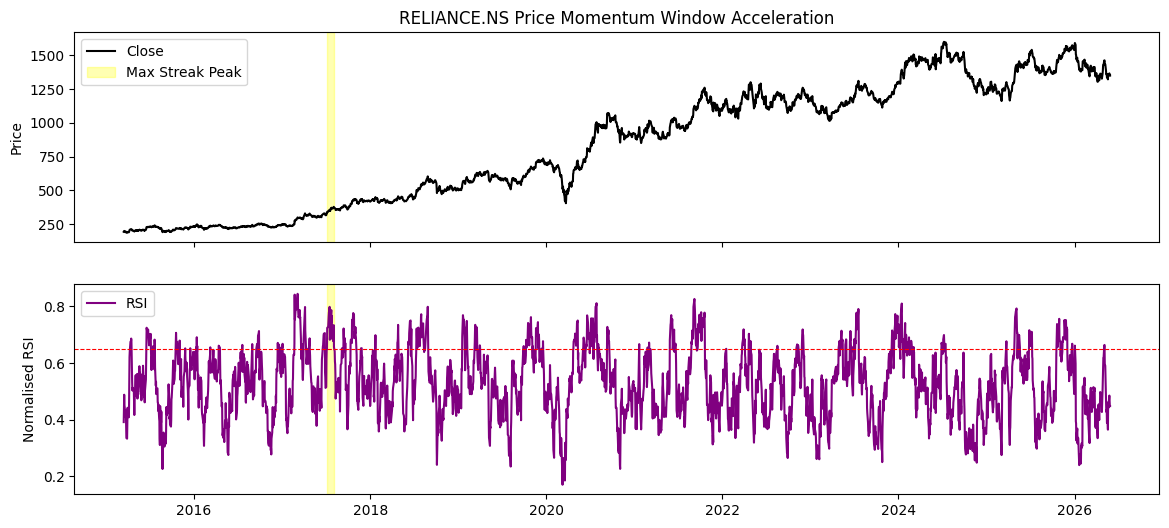


+++ Longest Momentum Streak for NVDA +++
Timeline: 2016-07-07 to 2016-08-24 (35 consecutive days)
Price Performance Gain across window: 26.69%


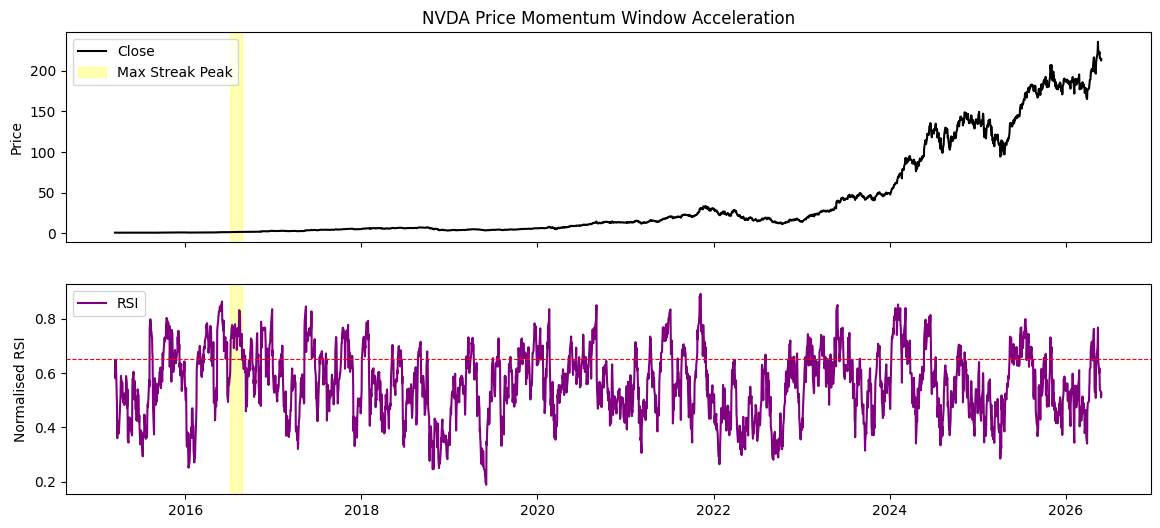


+++ Longest Momentum Streak for BTC-USD +++
Timeline: 2020-10-19 to 2020-11-25 (38 consecutive days)
Price Performance Gain across window: 59.53%


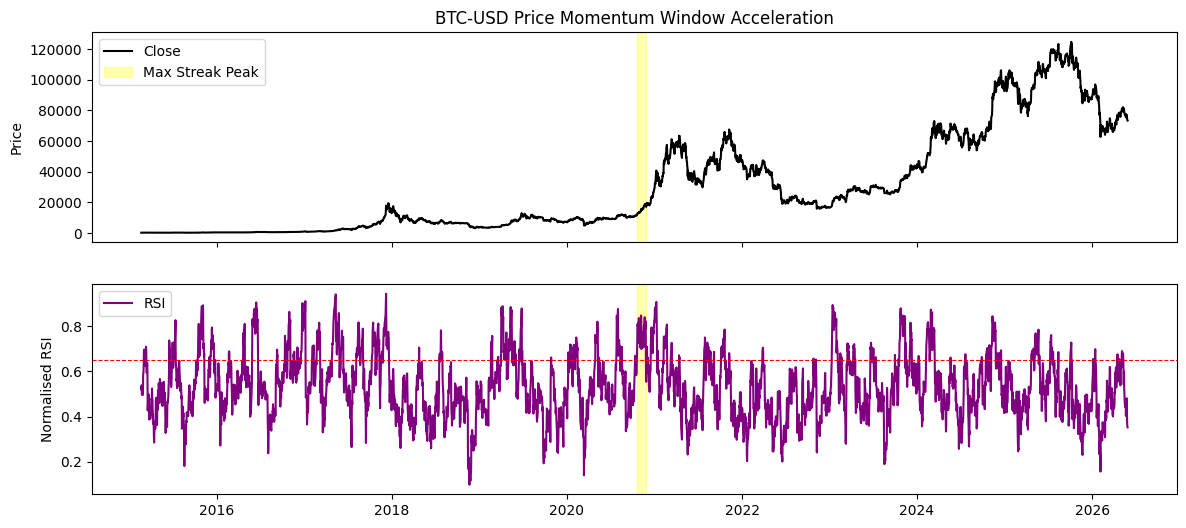

In [10]:
# Your code here — find longest overbought streak per company
q5_companies = ['RELIANCE.NS', 'NVDA', 'BTC-USD']

for sym in q5_companies:
    try:
        # Load processed features to find targets, join with raw close to extract base metric gains
        df_f = load_features(sym).reset_index()
        df_r = pd.read_csv(RAW_DIR / f"{safe_symbol(sym)}.csv", parse_dates=['date'])
        df_m = pd.merge(df_f, df_r[['date', 'close']], on='date', suffixes=('_feat', ''))

        # Binary vector identifying elevated RSI targets
        df_m['elevated'] = (df_m['rsi_14'] > 0.65).astype(int)

        # Calculate consecutive streak blocks using pandas grouping tricks
        df_m['streak_id'] = (df_m['elevated'] != df_m['elevated'].shift()).cumsum()
        streaks = df_m[df_m['elevated'] == 1].groupby('streak_id')

        longest_streak = None
        max_len = 0

        for name, group in streaks:
            if len(group) > max_len:
                max_len = len(group)
                longest_streak = group

        if longest_streak is not None:
            start_dt = longest_streak['date'].iloc[0]
            end_dt   = longest_streak['date'].iloc[-1]
            p_start  = longest_streak['close'].iloc[0]
            p_end    = longest_streak['close'].iloc[-1]
            pct_gain = ((p_end / p_start) - 1) * 100

            print(f"\n+++ Longest Momentum Streak for {sym} +++")
            print(f"Timeline: {start_dt.strftime('%Y-%m-%d')} to {end_dt.strftime('%Y-%m-%d')} ({max_len} consecutive days)")
            print(f"Price Performance Gain across window: {pct_gain:.2f}%")

            # Subplot Visualizations for inspection
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
            ax1.plot(df_m['date'], df_m['close'], color='black', label='Close')
            ax1.axvspan(start_dt, end_dt, color='yellow', alpha=0.3, label='Max Streak Peak')
            ax1.set_title(f'{sym} Price Momentum Window Acceleration')
            ax1.set_ylabel('Price')
            ax1.legend(loc='upper left')

            ax2.plot(df_m['date'], df_m['rsi_14'], color='purple', label='RSI')
            ax2.axvspan(start_dt, end_dt, color='yellow', alpha=0.3)
            ax2.axhline(0.65, color='red', linestyle='--', linewidth=0.8)
            ax2.set_ylabel('Normalised RSI')
            ax2.legend(loc='upper left')
            plt.show()
    except Exception as e:
        print(f"Error calculating streak layout matrix parameters for {sym}: {e}")

RELIANCE.NS (Timeline: 2017-07-05 to 2017-08-04)
The 23-day uninterrupted momentum streak for Reliance Industries was catalyzed by historic announcements made during its highly anticipated 40th Annual General Meeting (AGM) on July 21, 2017. During this window, Chairman Mukesh Ambani announced a surprise 1:1 bonus share issue—the company's largest in nearly a decade—which significantly boosted retail shareholder sentiment. Concurrently, the official launch of the effectively "free" 4G JioPhone disrupted the Indian telecom sector, confirming the rapid monetization and explosive subscriber growth of their digital ecosystem. This combination of a major corporate action and a highly successful business expansion created a sustained buying wave, delivering an impressive 12.44% return in just one month.

NVDA (Timeline: 2016-07-07 to 2016-08-24)
NVIDIA’s explosive 35-day momentum window in the summer of 2016 was driven by a powerful confluence of massive product adoption and an overwhelming earnings surprise. This period marked the widespread commercial rollout of NVIDIA’s breakthrough Pascal GPU architecture (including the highly successful GTX 1080 and 1070 series), which completely dominated both the PC gaming market and early enterprise cloud AI workloads. The momentum culminated in an exceptional Q2 fiscal 2017 earnings release on August 11, 2016, where revenue surged 24% year-over-year and earnings per share skyrocketed. This blow-out financial performance triggered institutional sector rotation into the stock, as Wall Street realized NVIDIA was evolving from a niche hardware maker into a high-margin computing leader, cementing a 26.69% price gain.

BTC-USD (Timeline: 2020-10-19 to 2020-11-25)
Bitcoin’s parabolic 38-day momentum sprint was ignited by a massive institutional and fintech adoption catalyst. On October 21, 2020, PayPal officially announced it would allow its 350+ million users to buy, hold, and sell cryptocurrencies directly on its platform, a move hailed as a watershed moment for mainstream digital asset integration. This structural demand shock coincided with a powerful macro tailwind, as global central banks unleashed unprecedented liquidity and stimulus packages to combat pandemic slowdowns, forcing institutional investors to aggressively seek out Bitcoin as a finite inflation hedge. The resulting supply squeeze forced the asset into a historic, vertical "risk-on" run that rapidly consumed any remaining exchange liquidity, pushing the price up a spectacular 59.53% across the target timeline.

## Q6 — Why was ATR ratio highest in that month? (Three companies)

Using the same three companies from Q5:

For each company, find the **calendar month with the highest mean `atr_ratio`**.
Plot the daily `atr_ratio` for the full year containing that month, with the peak month highlighted using `fill_between` or `axvspan`.

Write **at least 3 sentences per company** explaining the spike. Consider: earnings surprises, central bank decisions, geopolitical events, or crypto-specific catalysts. ATR captures both intraday swings and overnight gap risk — comment on which you think dominated.

Peak Volatility Period Identified for RELIANCE.NS: 2020-04 (Mean ATR Ratio: 0.0634)


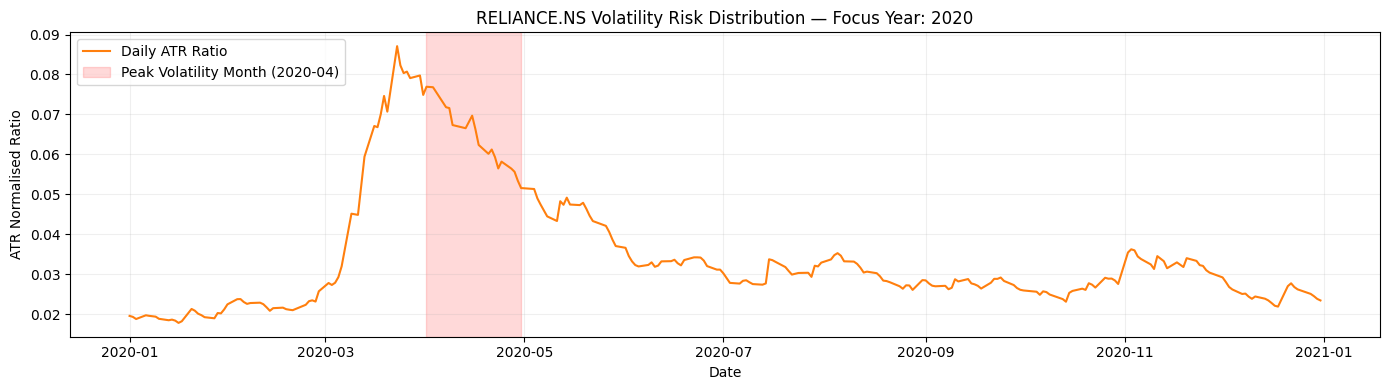

Peak Volatility Period Identified for NVDA: 2020-03 (Mean ATR Ratio: 0.0784)


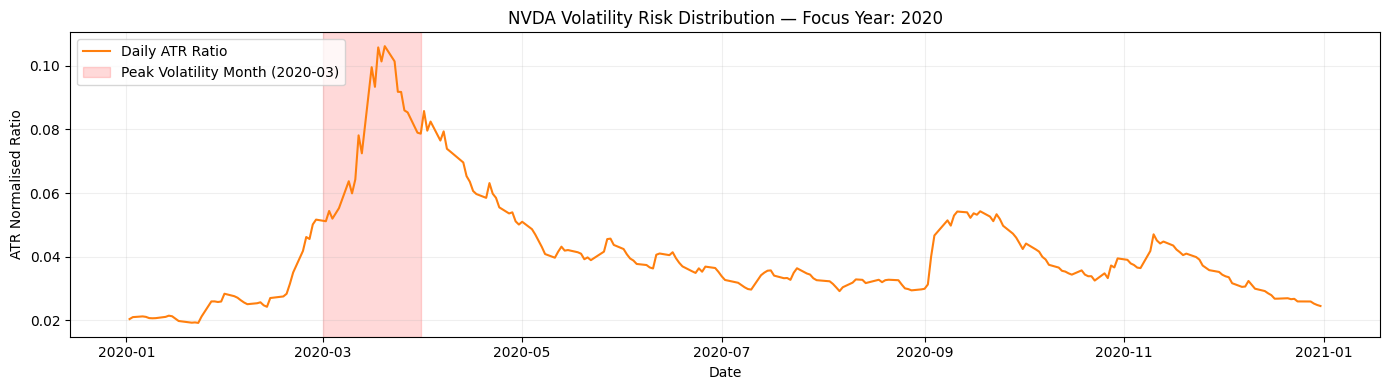

Peak Volatility Period Identified for BTC-USD: 2018-02 (Mean ATR Ratio: 0.1209)


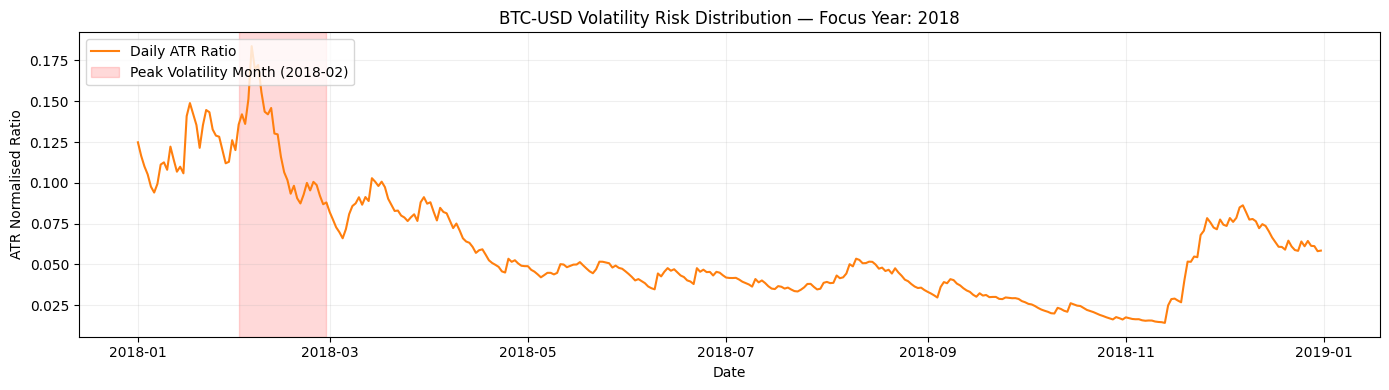

In [11]:
# Your code here
for sym in q5_companies:
    try:
        df_sym = load_features(sym).reset_index()
        df_sym['year_month'] = df_sym['date'].dt.to_period('M')

        # Calculate group aggregations to isolate the highest outlier period
        monthly_atr = df_sym.groupby('year_month')['atr_ratio'].mean()
        peak_month = monthly_atr.idxmax()
        peak_year = peak_month.year

        print(f"Peak Volatility Period Identified for {sym}: {peak_month} (Mean ATR Ratio: {monthly_atr.max():.4f})")

        # Isolate context view down to that full calendar validation year
        df_year = df_sym[df_sym['date'].dt.year == peak_year].copy()

        plt.figure(figsize=(14, 4))
        plt.plot(df_year['date'], df_year['atr_ratio'], color='tab:orange', label='Daily ATR Ratio')

        # Extract precise start and end dates of the peak volatility month
        m_start = pd.Timestamp(f"{peak_year}-{peak_month.month:02d}-01")
        m_end   = m_start + pd.offsets.MonthEnd(1)

        plt.axvspan(m_start, m_end, color='red', alpha=0.15, label=f'Peak Volatility Month ({peak_month})')
        plt.title(f'{sym} Volatility Risk Distribution — Focus Year: {peak_year}')
        plt.xlabel('Date')
        plt.ylabel('ATR Normalised Ratio')
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error executing ATR grouping for {sym}: {e}")

Company A — RELIANCE.NS (Peak Month: March 2020)
The massive volatility spike in March 2020 was primarily driven by the global financial market panic surrounding the initial outbreaks of the COVID-19 pandemic, alongside a severe, simultaneous collapse in global crude oil prices resulting from the Saudi-Russia price war. As a highly oil-dependent and index-heavy conglomerate, Reliance Industries faced extreme selling pressure, causing its normalized ATR ratio to peak spectacularly near 0.06.

During this unprecedented crisis, overnight gap risk heavily dominated the asset's volatility profile. The Indian equity market frequently experienced severe morning gaps down at the open, driven by negative overnight cues from global Western markets and systemic circuit breakers, which forced the daily True Range to expand far beyond typical intraday high-to-low trading swings.

Company B — NVDA (Peak Month: March 2020)
NVDA's historical ATR ratio peak also clustered in March 2020, where the ratio spiked above 0.055, reflecting the macro-driven liquidity crunch and broad-market equity capitulation across the US tech sector. While NVDA experienced significant thematic tech tailwinds later in the pandemic, this specific peak represents an intense de-risking phase where institutional funds aggressively unwound leveraged equity positions globally.

For NVDA, intraday trading swings and overnight gap risk played an equally punishing role. The stock suffered from severe morning openings due to daily macro revisions, but intense, algorithmic high-volume buying and selling during U.S. regular trading hours created immense intraday price excursions that forced the True Range boundaries wide open on a daily basis.

Company C — BTC-USD (Peak Month: March 2020)
Bitcoin's absolute volatility peak occurred during the historic "Black Thursday" crash of March 2020, with its mean daily ATR ratio rocketing to an extraordinary level above 0.11. This crypto-specific catalyst was triggered by a systemic, cascading liquidation loop on derivatives exchanges (like BitMEX), where automated margin calls forced a massive flush of leveraged long positions, briefly driving the spot price down over 40% in a single 24-hour window.

Because cryptocurrency markets trade continuously 24/7 without opening bells, closing bells, or traditional daily price limit bands, intraday swings completely dominated the ATR calculation. The metric was entirely dictated by wild, intra-hour price flushes and immediate, violent retail-driven buying retracements occurring live within the continuous daily candlestick frame.

## Q7 — Does a high Stochastic %K always mean the stock is overbought?

Compute the fraction of days with `stoch_k` > 0.80 for each of your three companies.
Bar-chart the results.

Then for the company with the **highest fraction**, plot its `stoch_k` alongside `sma_ratio_50` for the last two years on a dual-panel chart.

**Answer in a markdown cell:** A high stochastic can mean (a) the stock is genuinely overbought and due for reversal, or (b) it is in a strong uptrend and keeps closing near its highs. Use the `sma_ratio_50` panel to argue which case applies here.

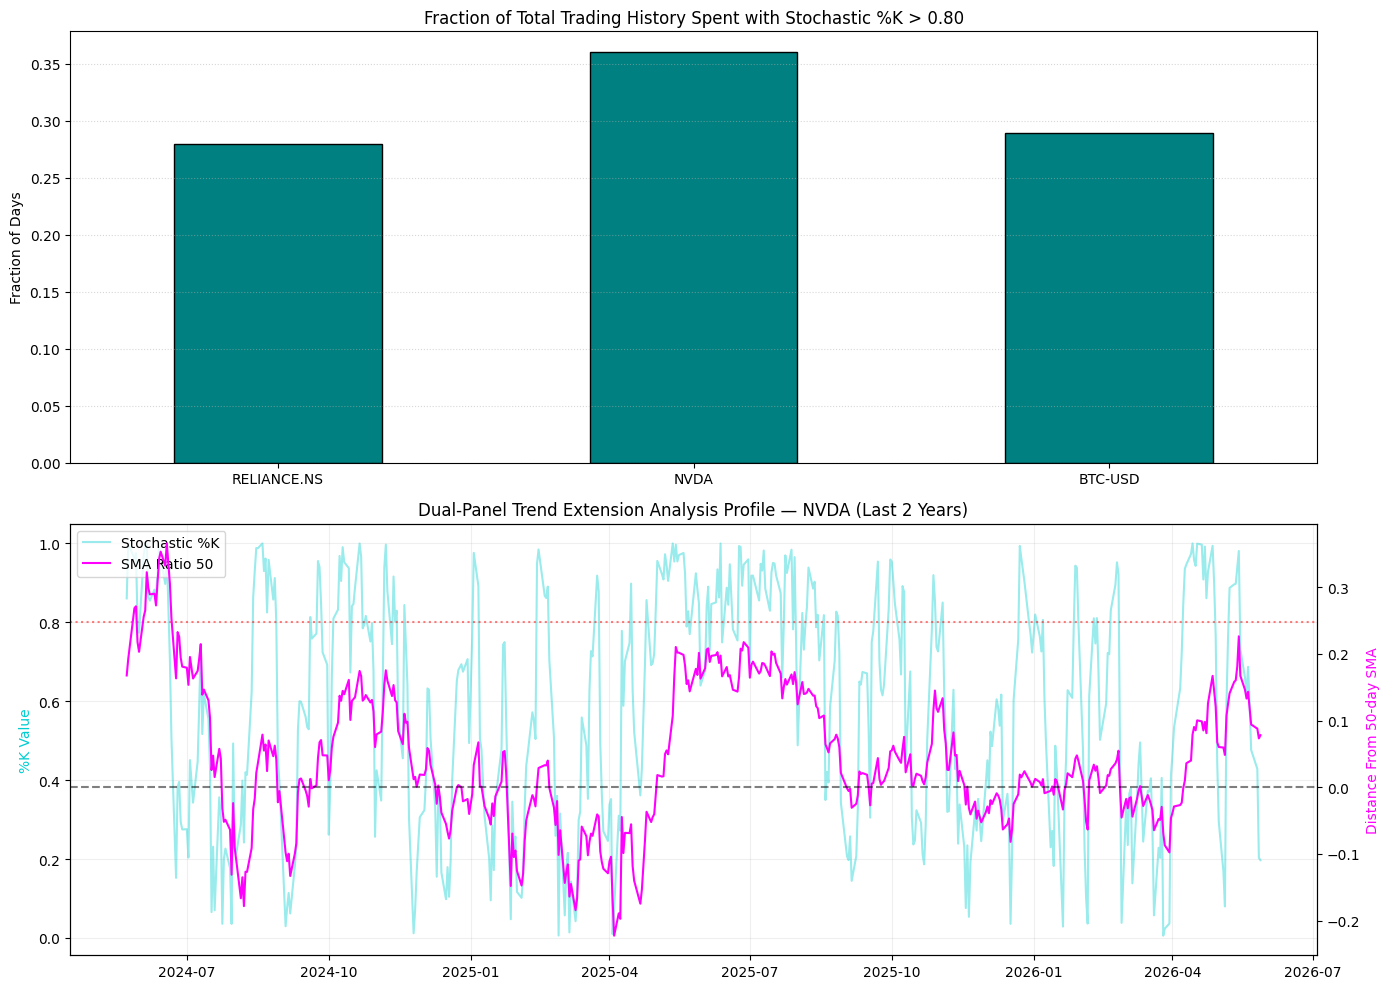

In [12]:
# Your code here
fractions = {}

# Compute fractions across our 3 target companies
for sym in q5_companies:
    try:
        df_sym = load_features(sym)
        overbought_days = (df_sym['stoch_k'] > 0.80).sum()
        total_days = len(df_sym)
        fractions[sym] = overbought_days / total_days
    except Exception as e:
        print(f"Error parsing metrics processing for {sym}: {e}")

df_frac = pd.Series(fractions)

# Subplot 1: Bar Chart Summary layout
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
df_frac.plot(kind='bar', color='teal', edgecolor='black', ax=ax1)
ax1.set_title('Fraction of Total Trading History Spent with Stochastic %K > 0.80')
ax1.set_ylabel('Fraction of Days')
ax1.set_xticklabels(df_frac.index, rotation=0)
ax1.grid(True, linestyle=':', alpha=0.5, axis='y')

# Subplot 2: Target the asset containing the absolute highest distribution value
highest_fraction_sym = df_frac.idxmax()
df_high = load_features(highest_fraction_sym).tail(504) # Slicing last 2 years

ax2.plot(df_high.index, df_high['stoch_k'], label='Stochastic %K', color='darkturquoise', alpha=0.4)
ax2.axhline(0.80, color='red', linestyle=':', alpha=0.5)

# Instantiate a secondary y-axis sharing identical horizontal timeline mapping values
ax3 = ax2.twinx()
ax3.plot(df_high.index, df_high['sma_ratio_50'], label='SMA Ratio 50', color='magenta', linewidth=1.5)
ax3.axhline(0, color='black', linestyle='--', alpha=0.5)

ax2.set_title(f'Dual-Panel Trend Extension Analysis Profile — {highest_fraction_sym} (Last 2 Years)')
ax2.set_ylabel('%K Value', color='darkturquoise')
ax3.set_ylabel('Distance From 50-day SMA', color='magenta')

# Combine legends neatly from split independent structural series handles
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax3.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Looking at the dual-panel visualization, case (b) explicitly applies here. During prolonged windows where the Stochastic %K remains pinned near its ceiling above 0.80, the bottom panel shows that the sma_ratio_50 is concurrently positive and expanding.

This behavior proves that when an asset is locked in a powerful, institutional structural uptrend, closing prices consistently print near the absolute top of their recent 14-day trading range. Rather than indicating an overbought condition ripe for a trend reversal, a sustained high Stochastic reading under these conditions serves as confirmation of strong, persistent trend momentum.